# Overall

```
- 프로젝트명 : 코호트 분석
- 프로젝트유형 : 이커머스 데이터 활용 코호트 분석
- 시나리오 : 특정 코호트에서 재구매율, 이탈률 패턴 분석 통해, 대내외 이슈 파악 위한 가이드라인 제시
- 문제정의 : 월 첫 구매 고객 기준 구매 패턴 분석 통한 저성과 원인 파악 및 대응 방향 수립
- 기대효과 : 저성과 원인 구체화, 해소 방안 마련
- 해결방안 : 긍/부정적 구매 패턴 파악 이후 추가 원인 분석 통한 재현 통한 개선 도모
- 성과측정 : 파악된 대내외 액션/이슈에 기반한 매출 추이 모니터링
- Meta data
    - InvoiceNo : 송장번호
    - StockCode : 재고코드
    - Description : 상세설명
    - Quantity : 수량
    - InvoiceDate : 송장날짜
    - UnitPrice : 개당가격
    - CustomerID : 고객 ID
    - Country : 나라

- 분석결과 / 제안
    - 2011년 연간 구매 데이터 기반의 코호트 분석 수행,
    기고객 구매 수, 매출 증대 패턴 보인 2011-08 ~ 2011-11 기간에 대한 대내외 이슈 파악 및 재현 위한 전략 수립 의견드립니다.
    이하 상세 분석 내용입니다.

    - Retention - 재방문 추이
        - 최초 구매월 이후 1개월 뒤 재방문 고객은 저하 추세를 보입니다. 2011-09 시기 반등 후 다시 저하세 강해지는 추세입니다.
        - 다만 1개월 뒤 재방문 고객 규모 수준 비례, 장기 방문 고객 규모 수준 유지하는 패턴 보이므로, 1개월 뒤 고객 재방문 유도를 위한 전략 수립을 제안드립니다.

    - Retention - 매출 추이
        - 2011-08 ~ 11 기간의 재방문 고객 대상으로 고매출 발생 패턴을 보였습니다.
        - 해당 기간의 프로모션 집행 이력 또는 마켓 이슈 등 기고객 대상의 매출 촉진 기여한 대내외 이슈 파악을 통해, 재현가능성 등을 검토해볼 수 있겠습니다.
        - 해당 기간의 이슈는 2011-01 첫 구매 고객의 매출 촉진에 높게 기여한 바, 해당 고객군과 이슈의 상관관계 등을 추가적으로 분석해볼 수 있겠습니다.

    - Retention - 구매 횟수 추이
        - 2011-08 ~ 11 기간의 재방문 고객 대상으로 고빈도 구매 횟수 발생 패턴을 보였습니다.
        - 앞서 '매출 추이' 분석에서 보인 패턴 발생 시점에 구매 수 증가 패턴을 보임을 확인, 해당 이슈는 매출 증대와 더불어 구매 횟수 증대에도 기여한 것으로 사료됩니다.

```
<!--

## 향후 진행방향
- 코호트 분석 이후 추가 분석 방향 검토

1. LTV (Lifetime Value) 분석
- 고객의 첫 구매 시점을 기준으로 기간별 매출 기여도 분석, 각 코호트별 LTV 누적 곡선을 통해 장기 고객 가치 확인
- 추천 지표: 누적 매출, 구매 빈도, ARPU (Average Revenue per User)

2. 고객 이탈 분석 (Churn Rate)
- 특정 기간 동안 재구매 없이 이탈한 고객 비율을 계산, Retention이 낮아지는 시점을 기준으로 이탈 패턴 탐색
- 예시: N개월 후 재구매율, 최초 이후 마지막 구매까지의 간격

3. 고객 세그먼트별 행동 분석
- RFM, k-means 등으로 클러스터링하여 군집별 매출/이탈률/재방문률 분석
- 코호트와 세그먼트를 교차하여, 가치 높은 코호트 추출

4. 캠페인 효과 분석
- 특정 시점(마케팅 집행 후 등)을 기준으로 코호트에 미친 영향 확인, 동일 코호트 내의 before/after 비교 또는 A/B 분석 설계 가능

5. 시계열 기반 재구매 예측 모델링
- ARIMA, Prophet 등을 활용하여 재구매 수요 예측, 기간별 반복구매율 분석을 기반으로 마케팅 타이밍 개선

6. 코호트별 품목 또는 카테고리 성과 비교
- 고객의 첫 구매 상품/카테고리를 기준으로 이후 행동 패턴 비교
- 특정 제품으로 유입된 고객군의 LTV가 높은가?

 -->


In [ ]:
# pandas
import pandas as pd

# Warnings 제거
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# ## 색상 변경
# plt.style.use(['dark_background'])

## 한글 깨짐 현상 방지
%pip install koreanize_matplotlib
import koreanize_matplotlib

## 과학표기법을 숫자로 변경하는 과정
pd.options.display.float_format = '{:.2f}'.format


In [ ]:
# Data read
import pandas as pd
df = pd.read_csv('P_PJT06_DATA.csv', encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.00,United Kingdom


In [ ]:
# shape
df.shape

(541909, 8)

In [ ]:
#info
df.info()

# Column	Description
# InvoiceNo	송장번호
# StockCode	재고코드
# Description	상세설명
# Quantity	수량
# InvoiceDate	송장날짜
# UnitPrice	개당가격
# CustomerID	고객ID
# Country	나라

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
#isna
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
#nunique
df.nunique()

,0
InvoiceNo,25900
StockCode,4070
Description,4223
Quantity,722
InvoiceDate,23260
UnitPrice,1630
CustomerID,4372
Country,38


# Preropcessing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   InvoiceNo           541909 non-null  object        
 1   StockCode           541909 non-null  object        
 2   Description         540455 non-null  object        
 3   Quantity            541909 non-null  int64         
 4   InvoiceDate         541909 non-null  datetime64[ns]
 5   UnitPrice           541909 non-null  float64       
 6   CustomerID          406829 non-null  float64       
 7   Country             541909 non-null  object        
 8   InvoiceDate_yymmdd  541909 non-null  datetime64[ns]
 9   total_price         541909 non-null  float64       
 10  year                541909 non-null  int32         
 11  month               541909 non-null  int32         
 12  day                 541909 non-null  int32         
dtypes: datetime64[ns](2), float64

## object type

In [ ]:
df.describe(include = 'object')

,InvoiceNo,StockCode,Description,Country
count,541909,541909,540455,541909
unique,25900,4070,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2313,2369,495478


In [ ]:
# Description
tmp = df['Description'].value_counts().sort_values(ascending=False).reset_index()

# len(df['Description'].value_counts().sort_values(ascending=False).index.tolist()) # 4223
# len(tmp[tmp['count'] > tmp['count'].mean()]) # 1318

# 뒷자리에 upper lower 구분 없이 동일한 description 갖는 제품들을 구분할 수 있는가? > 유의미한 정보라고 판단되지 않아 처리 없이 그대로 진행하겠습니다.
for i in tmp[tmp['count'] > tmp['count'].mean()]['Description'][:10] :
    if len(df[df['Description'] == i]['StockCode'].value_counts()) >= 2 :
        display(df[df['Description'] == i]['StockCode'].value_counts())

In [ ]:
# 결측치 확인
# CustomerID na 값에 description na 도 포함
# 분석 과정에서 Description 과 CustomerID 는 분석 과정에서 사용하지 않을 것으로 예상되므로 그대로 유지 하겠습니다.
df[df['CustomerID'].isna()].isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


## numeric, datetime type

In [ ]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,InvoiceDate_yymmdd,total_price,year,month,day
count,541909.00,541909,541909.00,406829.00,541909,541909.00,541909.00,541909.00,541909.00
mean,9.55,2011-07-04 13:34:57.156386048,4.61,15287.69,2011-07-04 00:00:13.073782272,17.99,2010.92,7.55,15.02
min,-80995.00,2010-12-01 08:26:00,-11062.06,12346.00,2010-12-01 00:00:00,-168469.60,2010.00,1.00,1.00
25%,1.00,2011-03-28 11:34:00,1.25,13953.00,2011-03-28 00:00:00,3.40,2011.00,5.00,7.00
50%,3.00,2011-07-19 17:17:00,2.08,15152.00,2011-07-19 00:00:00,9.75,2011.00,8.00,15.00
75%,10.00,2011-10-19 11:27:00,4.13,16791.00,2011-10-19 00:00:00,17.40,2011.00,11.00,22.00
max,80995.00,2011-12-09 12:50:00,38970.00,18287.00,2011-12-09 00:00:00,168469.60,2011.00,12.00,31.00
std,218.08,NaN,96.76,1713.60,NaN,378.81,0.27,3.51,8.66


In [ ]:
# InvoiceDate

# 데이터 타입 형변환
# 12/1/2010 8:26
# format='%m/%d/%Y %H:%M'
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%Y %H:%M')

# dt 컬럼으로 y, m, d 컬럼 추가
df['year'] = df['InvoiceDate'].dt.year
df['month'] = df['InvoiceDate'].dt.month
df['day'] = df['InvoiceDate'].dt.day

# yymmdd column 추가
df['InvoiceDate_yymmdd'] = df['InvoiceDate'].dt.strftime('%Y-%m-%d')
df['InvoiceDate_yymmdd'] = pd.to_datetime(df['InvoiceDate_yymmdd'], format='%Y-%m-%d')

# df의 total_price 컬럼 추가
df['total_price'] = df['Quantity'] * df['UnitPrice']

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   InvoiceNo           541909 non-null  object        
 1   StockCode           541909 non-null  object        
 2   Description         540455 non-null  object        
 3   Quantity            541909 non-null  int64         
 4   InvoiceDate         541909 non-null  datetime64[ns]
 5   UnitPrice           541909 non-null  float64       
 6   CustomerID          406829 non-null  float64       
 7   Country             541909 non-null  object        
 8   InvoiceDate_yymmdd  541909 non-null  datetime64[ns]
 9   total_price         541909 non-null  float64       
 10  year                541909 non-null  int32         
 11  month               541909 non-null  int32         
 12  day                 541909 non-null  int32         
dtypes: datetime64[ns](2), float64

In [ ]:
df.nunique()

,0
InvoiceNo,25900
StockCode,4070
Description,4223
Quantity,722
InvoiceDate,23260
UnitPrice,1630
CustomerID,4372
Country,38
InvoiceDate_yymmdd,305
total_price,6204


In [ ]:
# data 집계 기간
df['InvoiceDate'].min(), df['InvoiceDate'].max()

(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

In [ ]:
df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country',
 'year',
 'month',
 'day']

## InvoiceNo

,count
count,25900.00
mean,20.92
std,43.03
min,1.00
25%,2.00
50%,10.00
75%,23.00
max,1114.00


<Axes: >

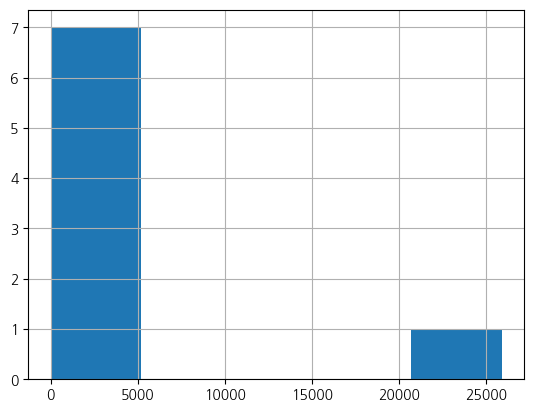

In [ ]:
# InvoiceNo
display(df['InvoiceNo'].value_counts().sort_values(ascending=False).reset_index()['count'].describe())
df['InvoiceNo'].value_counts().sort_values(ascending=False).reset_index()['count'].describe().hist(bins = 5)

## StockCode

,StockCode
0,85123A
1,71053
2,84406B
3,84029G
4,84029E


<Axes: >

,count
StockCode,
85123A,2302
85123a,67


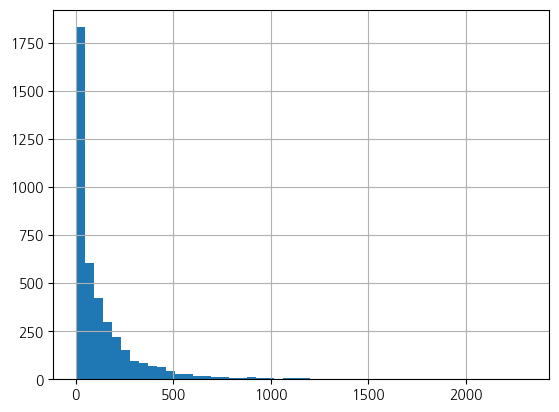

In [ ]:
# StockCode도 처리 없이 그대로 사용
display(df['StockCode'].head(5))
display(df['StockCode'].value_counts().sort_values(ascending=False).hist(bins = 50))

# Description
tmp = df['Description'].value_counts().sort_values(ascending=False).reset_index()

# len(df['Description'].value_counts().sort_values(ascending=False).index.tolist()) # 4223
# len(tmp[tmp['count'] > tmp['count'].mean()]) # 1318

# 뒷자리에 upper lower 구분 없이 동일한 description 갖는 제품들을 구분할 수 있는가? > 유의미한 정보라고 판단되지 않아 처리 없이 그대로 진행하겠습니다.
for i in tmp[tmp['count'] > tmp['count'].mean()]['Description'][:10] :
    if len(df[df['Description'] == i]['StockCode'].value_counts()) >= 2 :
        display(df[df['Description'] == i]['StockCode'].value_counts())

## Quantity

,Quantity
count,541909.00
mean,9.55
std,218.08
min,-80995.00
25%,1.00
50%,3.00
75%,10.00
max,80995.00


<Axes: ylabel='Quantity'>

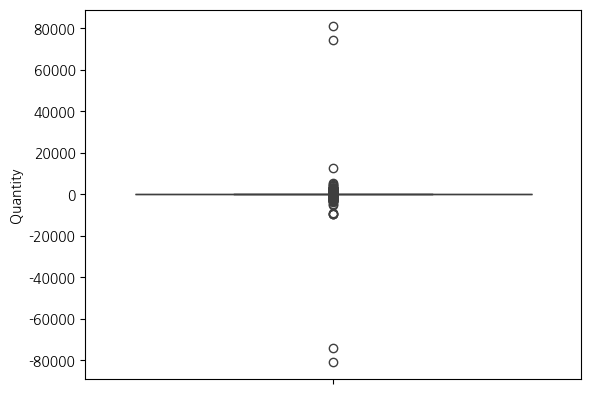

In [ ]:
# 'Quantity'
display(df['Quantity'].describe())
display(sns.boxplot(df['Quantity']))

In [ ]:
tmp = df.copy()

Q1 = tmp['Quantity'].quantile(0.25)
Q3 = tmp['Quantity'].quantile(0.75)
IQR = Q3 - Q1

# 조건 필터링 (IQR 기준 극단값 제거)
filtered_tmp = tmp[(tmp['Quantity'] >= Q1 - 1.5 * IQR) & (tmp['Quantity'] <= Q3 + 1.5 * IQR)]

,Quantity
count,483290.00
mean,4.57
std,4.55
min,-12.00
25%,1.00
50%,3.00
75%,6.00
max,23.00


<Axes: ylabel='Quantity'>

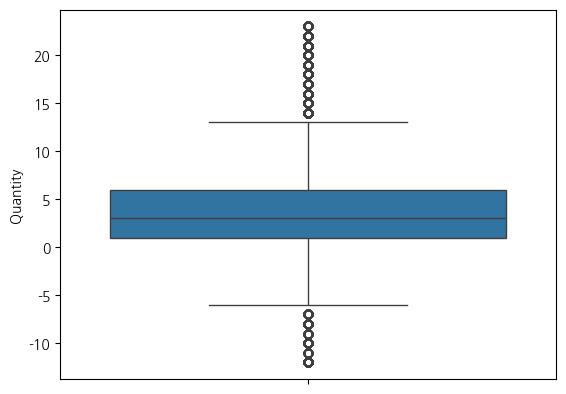

In [ ]:
display(filtered_tmp['Quantity'].describe())
display(sns.boxplot(filtered_tmp['Quantity']))

<Axes: xlabel='Quantity', ylabel='Count'>

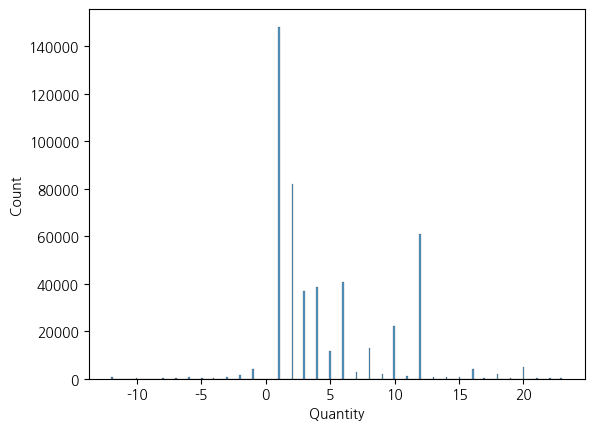

In [ ]:
sns.histplot(data=filtered_tmp, x="Quantity")

In [ ]:
df = filtered_tmp.copy()

## InvoiceDate

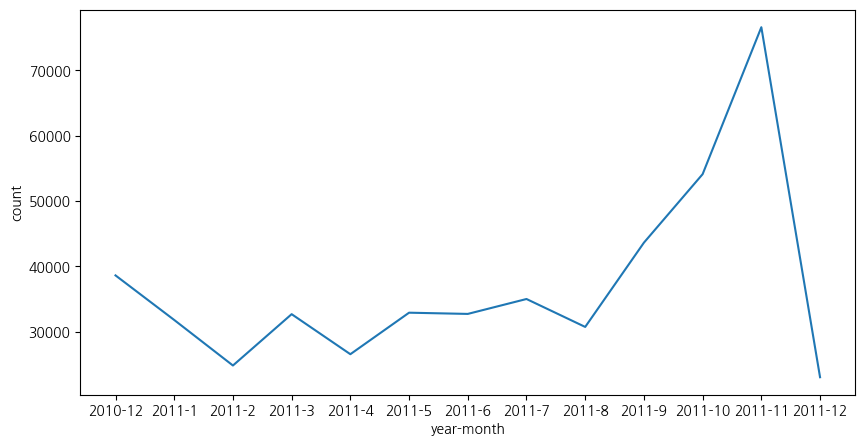

In [ ]:
# 1개년도 기준으로 분석 진행을 위해  year = 2010 데이터 제외 후 진행,

# 기간별 데이터 분포 파악
tmp = df[['year', 'month']].value_counts().reset_index().sort_values(by = ['year', 'month'], ascending = [True, True])
tmp['year-month'] = tmp['year'].astype(str) + '-' + tmp['month'].astype(str)
tmp.head()

plt.figure(figsize = (10, 5))
sns.lineplot(data = tmp, x = 'year-month', y = 'count')
plt.show()


In [ ]:
# 12개월 기준의 비교를 위해 2010년 12월 데이터를 제외하여 데이터 탐색을 진행하겠습니다.
df = df[df['year'] != 2010]

In [ ]:
df[['year', 'month']].value_counts().reset_index()

,year,month,count
0,2011,11,76586
1,2011,10,54109
2,2011,9,43630
3,2011,7,35011
4,2011,5,32917
5,2011,6,32730
6,2011,3,32692
7,2011,1,31804
8,2011,8,30740
9,2011,4,26566


## UnitPrice

In [ ]:
# 'UnitPrice'

Q1 = df['UnitPrice'].quantile(0.25)
Q3 = df['UnitPrice'].quantile(0.75)
IQR = Q3 - Q1

# 조건 필터링 (IQR 기준 극단값 제거)
filtered_df = df[(df['UnitPrice'] >= Q1 - 1.5 * IQR) & (df['UnitPrice'] <= Q3 + 1.5 * IQR)]

<Axes: xlabel='UnitPrice'>

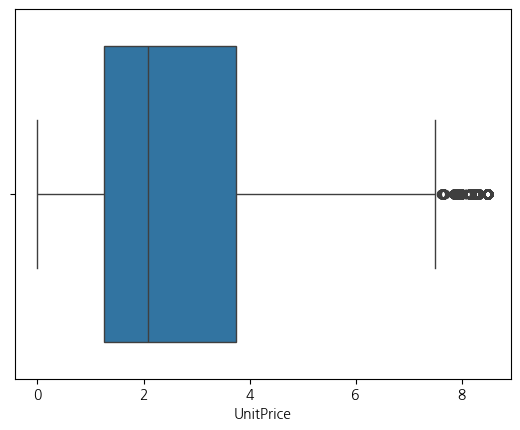

In [ ]:
sns.boxplot(data  = filtered_df, x = 'UnitPrice')

In [ ]:
df = filtered_df.copy()

In [ ]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,InvoiceDate_yymmdd,total_price,year,month,day
count,415311.00,415311,415311.00,311071.00,415311,415311.00,415311.00,415311.00,415311.00
mean,4.83,2011-07-22 17:21:50.406610688,2.75,15324.48,2011-07-22 03:42:28.893720832,10.65,2011.00,7.20,15.43
min,-12.00,2011-01-04 10:00:00,0.00,12347.00,2011-01-04 00:00:00,-102.00,2011.00,1.00,1.00
25%,1.00,2011-04-26 09:00:30,1.25,14016.00,2011-04-26 00:00:00,3.25,2011.00,4.00,8.00
50%,3.00,2011-08-08 12:34:00,2.08,15223.00,2011-08-08 00:00:00,7.46,2011.00,8.00,15.00
75%,8.00,2011-10-26 12:15:00,3.75,16813.00,2011-10-26 00:00:00,15.30,2011.00,10.00,23.00
max,23.00,2011-12-09 12:50:00,8.50,18287.00,2011-12-09 00:00:00,191.59,2011.00,12.00,31.00
std,4.62,NaN,2.03,1701.83,NaN,11.96,0.00,3.41,8.73


In [ ]:
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,743
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,104240
Country,0
InvoiceDate_yymmdd,0
total_price,0


In [ ]:
# finalize
df_final = df.copy()

# Analysis
- 첫 주문 고객의 동향 분석

In [ ]:
# 고객별 첫 구매일 column 생성
cohort = df_final.groupby('CustomerID')['InvoiceDate_yymmdd'].min().reset_index()
cohort.columns = ['CustomerID', 'CohortDate']
df_final = df_final.merge(cohort, on='CustomerID')


In [ ]:
from operator import attrgetter

# 년/월 추출
df_final['InvoiceYearMonth'] = df_final['InvoiceDate_yymmdd'].dt.to_period('M')
df_final['CohortYearMonth'] = df_final['CohortDate'].dt.to_period('M')

# 코호트 인덱스 = (구매 시점 - 첫 구매 시점) in months
df_final['CohortIndex'] = (df_final['InvoiceYearMonth'] - df_final['CohortYearMonth']).apply(attrgetter('n'))

# description
# Period 간의 차이는 pandas.Period 타입이기 때문에,
# (period1 - period2) 결과는 DateOffset이 아닌 pandas._libs.tslibs.offsets.MonthEnd(n) 같은 객체가 아니라 pandas._libs.tslibs.period.Period 객체 간의 차이로서 pandas.offsets를 쓰지 않습니다.
# 따라서 .apply(attrgetter('n'))을 통해 그 차이의 월 수(n)를 뽑아내기 위해 attrgetter를 사용합니다.
# attrgetter('n')은 lambda x: x.n과 같은 역할을 합니다.

In [ ]:
# 이 코드는 고객이 처음 구매한 달과 나중에 구매한 달 사이의 차이를 계산해서, 그 차이를 몇 개월로 표현하고 싶을 때 사용합니다.
# df_final['CohortIndex'] = (df_final['InvoiceYearMonth'] - df_final['CohortYearMonth']).apply(attrgetter('n'))

# attrgetter라는 도구를 쓰려면 미리 import 해줘야 하는데, 안 했기 때문에 오류가 났어요. 이 줄을 코드 맨 위에 추가하면 해결됩니다.
# from operator import attrgetter

# 그럼 attrgetter('n') 이게 뭔가요?
# 즉, 어떤 객체에서 n이라는 속성만 뽑아오는 역할을 해요.
# (df_final['InvoiceYearMonth'] - df_final['CohortYearMonth']) 이 부분의 결과는 몇 개월 차이를 담고 있는 특수한 객체인데, 이 객체는 .n이라는 속성에 "몇 개월 차이인지" 숫자로 담고 있어요.
# 그래서 .apply(lambda x: x.n) 또는 .apply(attrgetter('n')) 이렇게 써야 그 숫자를 뽑을 수 있는 거죠.

# 가장 간단한 해결 방법
# 이렇게만 써도 같은 결과가 나오고, import도 필요 없습니다.
# df_final['CohortIndex'] = (df_final['InvoiceYearMonth'] - df_final['CohortYearMonth']).apply(lambda x: x.n)

In [ ]:
df_final.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDate_yymmdd,total_price,year,month,day,CohortDate,InvoiceYearMonth,CohortYearMonth,CohortIndex
0,539993,22386,JUMBO BAG PINK POLKADOT,10,2011-01-04 10:00:00,1.95,13313.00,United Kingdom,2011-01-04,19.50,2011,1,4,2011-01-04,2011-01,2011-01,0
1,539993,22379,RECYCLING BAG RETROSPOT,5,2011-01-04 10:00:00,2.10,13313.00,United Kingdom,2011-01-04,10.50,2011,1,4,2011-01-04,2011-01,2011-01,0
2,539993,20718,RED RETROSPOT SHOPPER BAG,10,2011-01-04 10:00:00,1.25,13313.00,United Kingdom,2011-01-04,12.50,2011,1,4,2011-01-04,2011-01,2011-01,0


## Retention - 재방문 추이

In [ ]:
# 집계 기준은 크게 3가지로 설정
# - 고객 수 (Retention)
# - 총 매출
# - 구매 횟수

# 예: 고객 수 기준 코호트 테이블
cohort_data = df_final.groupby(['CohortYearMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='CohortYearMonth', columns='CohortIndex', values='CustomerID')

# cohort_pivot
cohort_pivot.style.background_gradient(cmap='YlGnBu')

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11
CohortYearMonth,,,,,,,,,,,,
2011-01,727.000000,262.000000,321.000000,273.000000,330.000000,315.000000,287.000000,286.000000,319.000000,312.000000,372.000000,202.000000
2011-02,469.000000,122.000000,110.000000,152.000000,143.000000,127.000000,132.000000,152.000000,151.000000,168.000000,68.000000,nan
2011-03,513.000000,91.000000,135.000000,123.000000,115.000000,97.000000,138.000000,124.000000,161.000000,55.000000,nan,nan
2011-04,354.000000,86.000000,88.000000,81.000000,74.000000,88.000000,90.000000,102.000000,33.000000,nan,nan,nan
2011-05,313.000000,64.000000,57.000000,56.000000,71.000000,75.000000,87.000000,32.000000,nan,nan,nan,nan
2011-06,257.000000,53.000000,45.000000,63.000000,58.000000,84.000000,30.000000,nan,nan,nan,nan,nan
2011-07,206.000000,41.000000,43.000000,49.000000,55.000000,26.000000,nan,nan,nan,nan,nan,nan
2011-08,176.000000,40.000000,43.000000,44.000000,28.000000,nan,nan,nan,nan,nan,nan,nan
2011-09,302.000000,90.000000,104.000000,40.000000,nan,nan,nan,nan,nan,nan,nan,nan


In [ ]:
# Retention 계산
cohort_size = cohort_pivot.iloc[:,0]
retention = cohort_pivot.divide(cohort_size, axis=0)

retention.style.background_gradient(cmap='YlGnBu')

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11
CohortYearMonth,,,,,,,,,,,,
2011-01,1.000000,0.360385,0.441541,0.375516,0.453920,0.433287,0.394773,0.393398,0.438790,0.429161,0.511692,0.277854
2011-02,1.000000,0.260128,0.234542,0.324094,0.304904,0.270789,0.281450,0.324094,0.321962,0.358209,0.144989,nan
2011-03,1.000000,0.177388,0.263158,0.239766,0.224172,0.189084,0.269006,0.241715,0.313840,0.107212,nan,nan
2011-04,1.000000,0.242938,0.248588,0.228814,0.209040,0.248588,0.254237,0.288136,0.093220,nan,nan,nan
2011-05,1.000000,0.204473,0.182109,0.178914,0.226837,0.239617,0.277955,0.102236,nan,nan,nan,nan
2011-06,1.000000,0.206226,0.175097,0.245136,0.225681,0.326848,0.116732,nan,nan,nan,nan,nan
2011-07,1.000000,0.199029,0.208738,0.237864,0.266990,0.126214,nan,nan,nan,nan,nan,nan
2011-08,1.000000,0.227273,0.244318,0.250000,0.159091,nan,nan,nan,nan,nan,nan,nan
2011-09,1.000000,0.298013,0.344371,0.132450,nan,nan,nan,nan,nan,nan,nan,nan


In [ ]:
# difference
retention.diff().style.background_gradient(cmap='YlGnBu')

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11
CohortYearMonth,,,,,,,,,,,,
2011-01,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
2011-02,0.000000,-0.100257,-0.206999,-0.051422,-0.149016,-0.162499,-0.113323,-0.069304,-0.116828,-0.070952,-0.366703,nan
2011-03,0.000000,-0.082740,0.028616,-0.084328,-0.080733,-0.081705,-0.012444,-0.082378,-0.008121,-0.250996,nan,nan
2011-04,0.000000,0.065550,-0.014570,-0.010953,-0.015132,0.059504,-0.014769,0.046420,-0.220620,nan,nan,nan
2011-05,0.000000,-0.038465,-0.066479,-0.049900,0.017798,-0.008971,0.023718,-0.185899,nan,nan,nan,nan
2011-06,0.000000,0.001753,-0.007011,0.066222,-0.001156,0.087232,-0.161224,nan,nan,nan,nan,nan
2011-07,0.000000,-0.007197,0.033641,-0.007272,0.041309,-0.200635,nan,nan,nan,nan,nan,nan
2011-08,0.000000,0.028244,0.035580,0.012136,-0.107899,nan,nan,nan,nan,nan,nan,nan
2011-09,0.000000,0.070741,0.100053,-0.117550,nan,nan,nan,nan,nan,nan,nan,nan


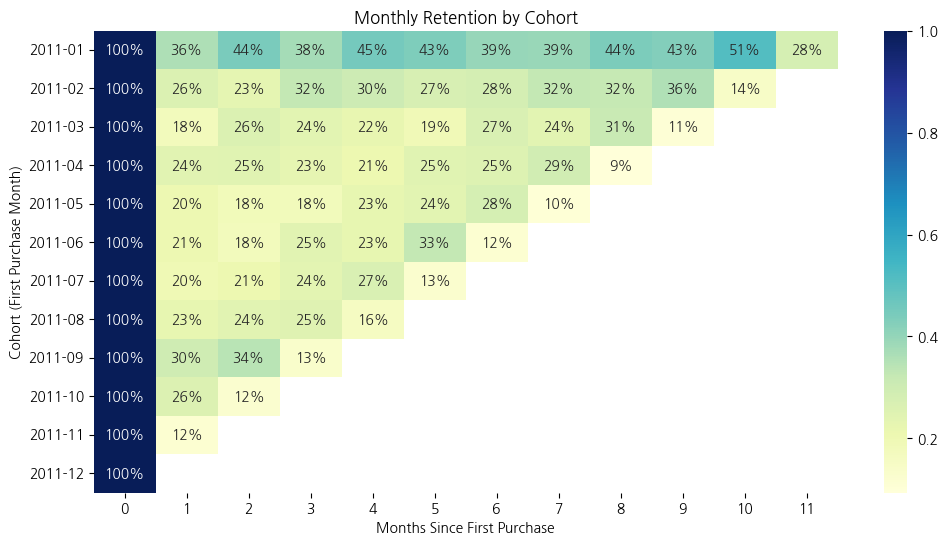

In [ ]:
# 시각화
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.heatmap(retention, annot=True, fmt='.0%', cmap='YlGnBu')
plt.title('Monthly Retention by Cohort')
plt.ylabel('Cohort (First Purchase Month)')
plt.xlabel('Months Since First Purchase')
plt.show()


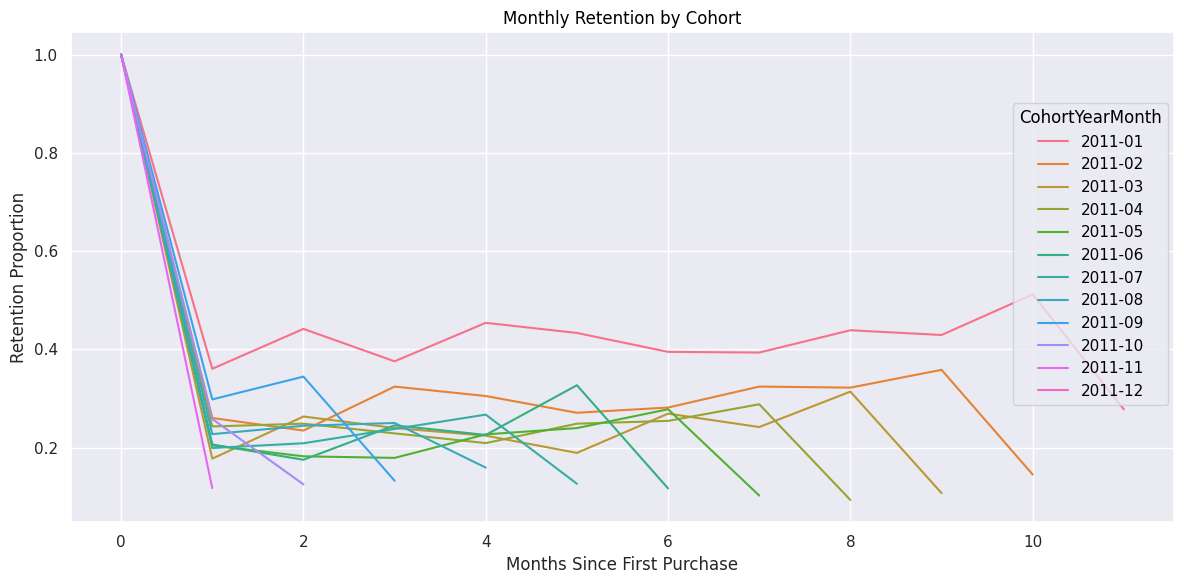

In [ ]:
import pandas as pd
import seaborn.objects as so

# Retention 테이블 long-form으로 변환
retention_long = retention.reset_index().melt(
    id_vars='CohortYearMonth',
    var_name='CohortIndex',
    value_name='Retention'
)

# 1. CohortYearMonth를 문자열로 변환
retention_long['CohortYearMonth'] = retention_long['CohortYearMonth'].astype(str)

# 2. 그래프 다시 그리기
import seaborn.objects as so

p = (
    so.Plot(retention_long, x='CohortIndex', y='Retention', color='CohortYearMonth')
    .add(so.Line(), so.Agg())
    .layout(size=(12, 6))
    .label(
        title='Monthly Retention by Cohort',
        x='Months Since First Purchase',
        y='Retention Proportion'
    )
    .theme({'legend.loc': 'upper right'})  # ← 여기서 범례 위치 설정
)

p.show()

## Retention - 매출 추이


In [ ]:
# 총매출 기준 코호트 테이블

cohort_revenue = df_final.groupby(['CohortYearMonth', 'CohortIndex'])['total_price'].sum().reset_index()
cohort_pivot_revenue = cohort_revenue.pivot_table(
    index='CohortYearMonth',
    columns='CohortIndex',
    values='total_price'
)

# # cohort_revenue
# cohort_revenue.head(3)

# cohort_pivot_revenue
cohort_pivot_revenue.style.background_gradient(cmap='YlGnBu')

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11
CohortYearMonth,,,,,,,,,,,,
2011-01,212903.540000,82505.750000,108208.810000,82281.990000,125994.950000,111209.040000,108802.940000,107555.000000,143488.391000,145290.350000,196473.030000,61196.110000
2011-02,122894.880000,20610.810000,28131.130000,45742.050000,40196.360000,30297.040000,42132.050000,50927.140000,50583.440000,57347.570000,13953.010000,nan
2011-03,138533.260000,17751.310000,37994.740000,30328.370000,30660.040000,30388.640000,43962.610000,45059.720000,53085.590000,10163.650000,nan,nan
2011-04,92227.011000,23083.420000,19672.800000,22133.980000,19009.000000,26104.630000,27524.190000,35074.680000,7693.720000,nan,nan,nan
2011-05,77385.630000,11654.100000,12544.990000,13122.020000,21493.910000,25555.410000,25448.650000,8795.440000,nan,nan,nan,nan
2011-06,59250.410000,7751.730000,9544.630000,16710.670000,16505.410000,24584.900000,5753.960000,nan,nan,nan,nan,nan
2011-07,51135.761000,7388.630000,12157.340000,13765.970000,15542.770000,5726.810000,nan,nan,nan,nan,nan,nan
2011-08,53740.510000,12773.330000,24217.950000,26649.280000,9949.690000,nan,nan,nan,nan,nan,nan,nan
2011-09,95574.401000,22780.250000,26828.270000,11662.370000,nan,nan,nan,nan,nan,nan,nan,nan


In [ ]:
# Retention 계산
cohort_size = cohort_pivot_revenue.iloc[:,0]
retention = cohort_pivot_revenue.divide(cohort_size, axis=0)
retention.style.background_gradient(cmap='YlGnBu')

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11
CohortYearMonth,,,,,,,,,,,,
2011-01,1.000000,0.387526,0.508253,0.386475,0.591794,0.522345,0.511043,0.505182,0.673960,0.682423,0.922827,0.287436
2011-02,1.000000,0.167711,0.228904,0.372205,0.327079,0.246528,0.342830,0.414396,0.411599,0.466639,0.113536,nan
2011-03,1.000000,0.128138,0.274264,0.218925,0.221319,0.219360,0.317343,0.325263,0.383197,0.073366,nan,nan
2011-04,1.000000,0.250289,0.213308,0.239995,0.206111,0.283048,0.298440,0.380308,0.083422,nan,nan,nan
2011-05,1.000000,0.150598,0.162110,0.169567,0.277751,0.330235,0.328855,0.113657,nan,nan,nan,nan
2011-06,1.000000,0.130830,0.161090,0.282035,0.278570,0.414932,0.097113,nan,nan,nan,nan,nan
2011-07,1.000000,0.144490,0.237746,0.269204,0.303951,0.111992,nan,nan,nan,nan,nan,nan
2011-08,1.000000,0.237685,0.450646,0.495888,0.185143,nan,nan,nan,nan,nan,nan,nan
2011-09,1.000000,0.238351,0.280706,0.122024,nan,nan,nan,nan,nan,nan,nan,nan


In [ ]:
# difference
retention.diff().style.background_gradient(cmap='YlGnBu')

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11
CohortYearMonth,,,,,,,,,,,,
2011-01,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
2011-02,0.000000,-0.219816,-0.279349,-0.014271,-0.264714,-0.275817,-0.168213,-0.090786,-0.262360,-0.215784,-0.809290,nan
2011-03,0.000000,-0.039573,0.045360,-0.153280,-0.105760,-0.027168,-0.025487,-0.089133,-0.028402,-0.393273,nan,nan
2011-04,0.000000,0.122152,-0.060956,0.021070,-0.015208,0.063688,-0.018904,0.055045,-0.299776,nan,nan,nan
2011-05,0.000000,-0.099691,-0.051198,-0.070428,0.071640,0.047187,0.030415,-0.266651,nan,nan,nan,nan
2011-06,0.000000,-0.019768,-0.001020,0.112468,0.000820,0.084698,-0.231742,nan,nan,nan,nan,nan
2011-07,0.000000,0.013660,0.076657,-0.012830,0.025381,-0.302940,nan,nan,nan,nan,nan,nan
2011-08,0.000000,0.093195,0.212900,0.226684,-0.118808,nan,nan,nan,nan,nan,nan,nan
2011-09,0.000000,0.000666,-0.169940,-0.373864,nan,nan,nan,nan,nan,nan,nan,nan


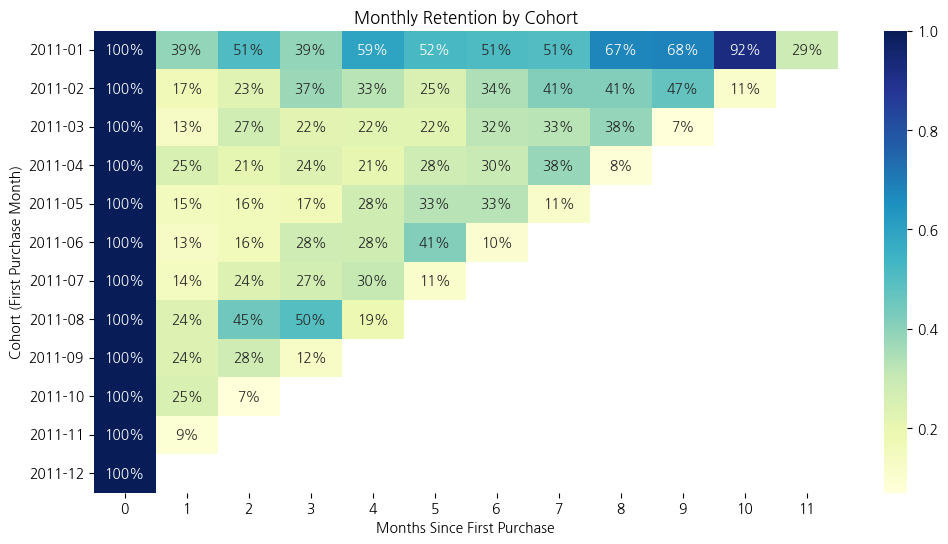

In [ ]:
# 시각화
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.heatmap(retention, annot=True, fmt='.0%', cmap='YlGnBu')
plt.title('Monthly Retention by Cohort')
plt.ylabel('Cohort (First Purchase Month)')
plt.xlabel('Months Since First Purchase')
plt.show()


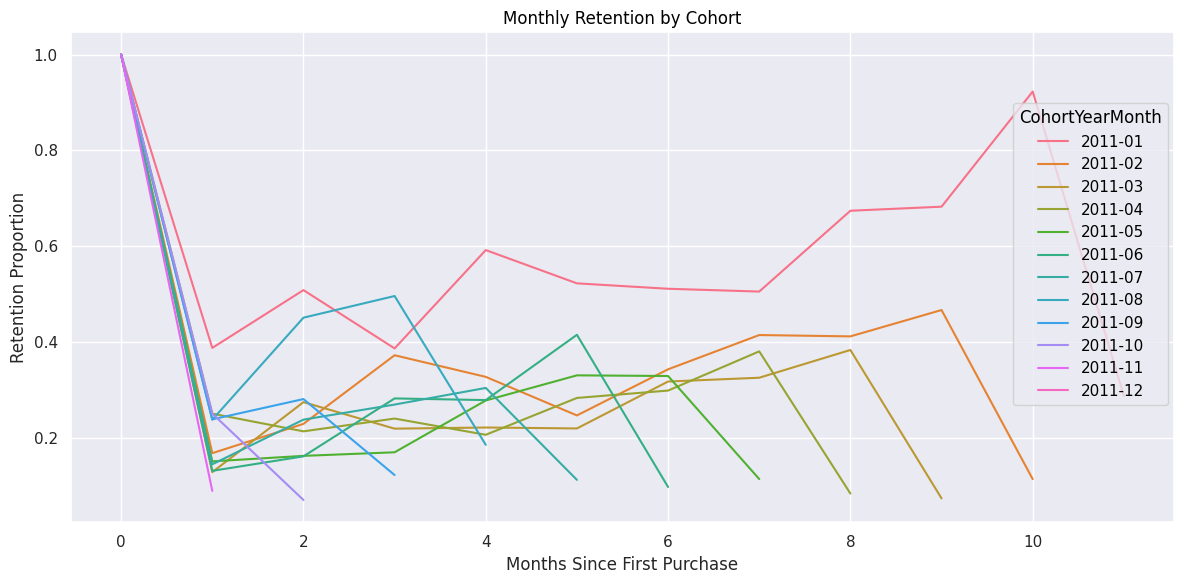

In [ ]:
import pandas as pd
import seaborn.objects as so

# Retention 테이블 long-form으로 변환
retention_long = retention.reset_index().melt(
    id_vars='CohortYearMonth',
    var_name='CohortIndex',
    value_name='Retention'
)

# 1. CohortYearMonth를 문자열로 변환
retention_long['CohortYearMonth'] = retention_long['CohortYearMonth'].astype(str)

# 2. 그래프 다시 그리기
import seaborn.objects as so

p = (
    so.Plot(retention_long, x='CohortIndex', y='Retention', color='CohortYearMonth')
    .add(so.Line(), so.Agg())
    .layout(size=(12, 6))
    .label(
        title='Monthly Retention by Cohort',
        x='Months Since First Purchase',
        y='Retention Proportion'
    )
    .theme({'legend.loc': 'upper right'})  # ← 여기서 범례 위치 설정
)

p.show()

## Retention - 구매 횟수 추이


In [ ]:
# 총구매 기준 코호트 테이블

cohort_purchase = df_final.groupby(['CohortYearMonth', 'CohortIndex'])['Quantity'].sum().reset_index()

cohort_pivot_purchase = cohort_purchase.pivot_table(
    index='CohortYearMonth',
    columns='CohortIndex',
    values='Quantity'
)

# cohort_purchase.head(3)

cohort_pivot_purchase.style.background_gradient(cmap= 'YlGnBu')

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11
CohortYearMonth,,,,,,,,,,,,
2011-01,97670.000000,35001.000000,50182.000000,38578.000000,56493.000000,49955.000000,50262.000000,50607.000000,65524.000000,64259.000000,90327.000000,29356.000000
2011-02,58848.000000,9654.000000,14432.000000,21909.000000,19646.000000,15832.000000,20918.000000,24294.000000,22636.000000,27066.000000,6458.000000,nan
2011-03,66162.000000,8376.000000,17179.000000,14710.000000,14956.000000,15589.000000,21255.000000,21751.000000,27030.000000,5251.000000,nan,nan
2011-04,44851.000000,10307.000000,9227.000000,11384.000000,9658.000000,12528.000000,13413.000000,16350.000000,3846.000000,nan,nan,nan
2011-05,35591.000000,5430.000000,5664.000000,6206.000000,10512.000000,13722.000000,12565.000000,4184.000000,nan,nan,nan,nan
2011-06,28879.000000,4276.000000,4238.000000,8161.000000,8862.000000,12580.000000,3204.000000,nan,nan,nan,nan,nan
2011-07,25400.000000,3305.000000,6069.000000,6600.000000,8208.000000,3225.000000,nan,nan,nan,nan,nan,nan
2011-08,26901.000000,5418.000000,10147.000000,10791.000000,4408.000000,nan,nan,nan,nan,nan,nan,nan
2011-09,46205.000000,10542.000000,12666.000000,5499.000000,nan,nan,nan,nan,nan,nan,nan,nan


In [ ]:
# Retention 계산
cohort_size = cohort_pivot_purchase.iloc[:,0]
retention = cohort_pivot_purchase.divide(cohort_size, axis=0)

# cohort_size.head(3)
retention.style.background_gradient(cmap = 'YlGnBu')

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11
CohortYearMonth,,,,,,,,,,,,
2011-01,1.000000,0.358360,0.513791,0.394983,0.578407,0.511467,0.514610,0.518143,0.670871,0.657920,0.924818,0.300563
2011-02,1.000000,0.164050,0.245242,0.372298,0.333843,0.269032,0.355458,0.412826,0.384652,0.459931,0.109740,nan
2011-03,1.000000,0.126598,0.259651,0.222333,0.226051,0.235619,0.321257,0.328754,0.408543,0.079366,nan,nan
2011-04,1.000000,0.229805,0.205726,0.253818,0.215335,0.279325,0.299057,0.364540,0.085751,nan,nan,nan
2011-05,1.000000,0.152567,0.159141,0.174370,0.295356,0.385547,0.353039,0.117558,nan,nan,nan,nan
2011-06,1.000000,0.148066,0.146750,0.282593,0.306867,0.435611,0.110946,nan,nan,nan,nan,nan
2011-07,1.000000,0.130118,0.238937,0.259843,0.323150,0.126969,nan,nan,nan,nan,nan,nan
2011-08,1.000000,0.201405,0.377198,0.401138,0.163860,nan,nan,nan,nan,nan,nan,nan
2011-09,1.000000,0.228157,0.274126,0.119013,nan,nan,nan,nan,nan,nan,nan,nan


In [ ]:
# difference
retention.diff().style.background_gradient(cmap='YlGnBu')

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11
CohortYearMonth,,,,,,,,,,,,
2011-01,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
2011-02,0.000000,-0.194310,-0.268549,-0.022685,-0.244564,-0.242435,-0.159152,-0.105316,-0.286219,-0.197989,-0.815078,nan
2011-03,0.000000,-0.037451,0.014409,-0.149965,-0.107792,-0.033413,-0.034201,-0.084073,0.023891,-0.380565,nan,nan
2011-04,0.000000,0.103207,-0.053925,0.031485,-0.010716,0.043706,-0.022200,0.035787,-0.322792,nan,nan,nan
2011-05,0.000000,-0.077239,-0.046584,-0.079448,0.080020,0.106222,0.053982,-0.246983,nan,nan,nan,nan
2011-06,0.000000,-0.004501,-0.012391,0.108223,0.011511,0.050064,-0.242093,nan,nan,nan,nan,nan
2011-07,0.000000,-0.017948,0.092187,-0.022750,0.016283,-0.308642,nan,nan,nan,nan,nan,nan
2011-08,0.000000,0.071287,0.138261,0.141295,-0.159290,nan,nan,nan,nan,nan,nan,nan
2011-09,0.000000,0.026752,-0.103072,-0.282124,nan,nan,nan,nan,nan,nan,nan,nan


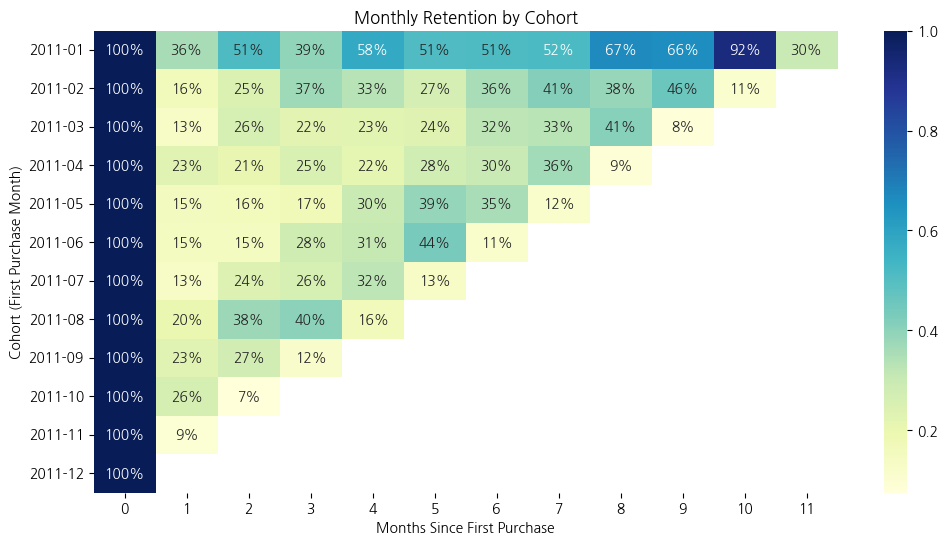

In [ ]:
# 시각화
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.heatmap(retention, annot=True, fmt='.0%', cmap='YlGnBu')
plt.title('Monthly Retention by Cohort')
plt.ylabel('Cohort (First Purchase Month)')
plt.xlabel('Months Since First Purchase')
plt.show()


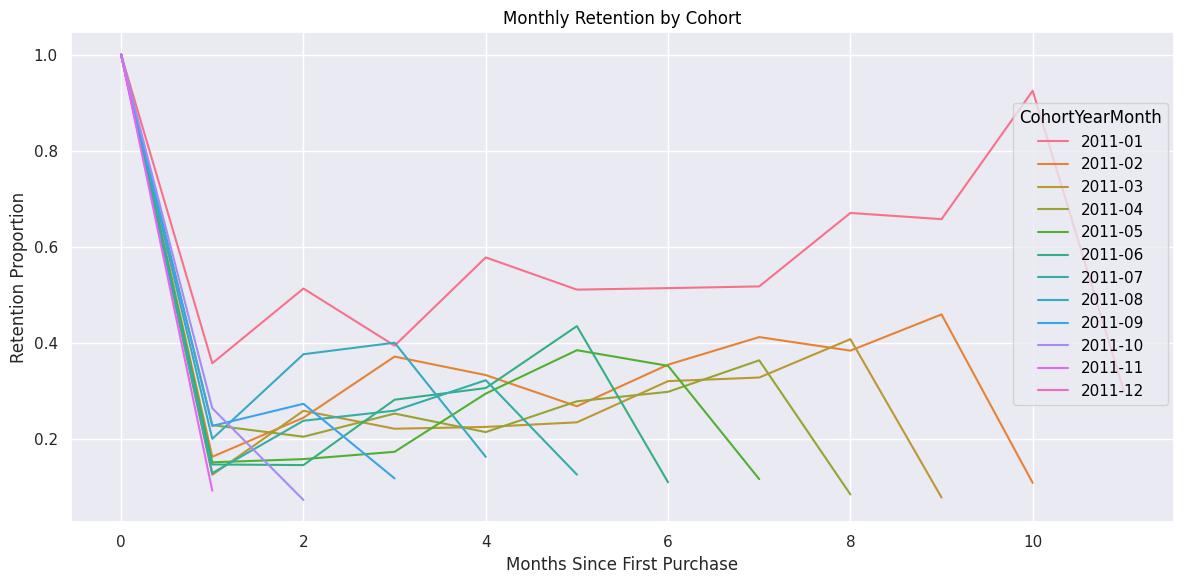

In [ ]:
import pandas as pd
import seaborn.objects as so

# Retention 테이블 long-form으로 변환
retention_long = retention.reset_index().melt(
    id_vars='CohortYearMonth',
    var_name='CohortIndex',
    value_name='Retention'
)

# 1. CohortYearMonth를 문자열로 변환
retention_long['CohortYearMonth'] = retention_long['CohortYearMonth'].astype(str)

# 2. 그래프 다시 그리기
import seaborn.objects as so

p = (
    so.Plot(retention_long, x='CohortIndex', y='Retention', color='CohortYearMonth')
    .add(so.Line(), so.Agg())
    .layout(size=(12, 6))
    .label(
        title='Monthly Retention by Cohort',
        x='Months Since First Purchase',
        y='Retention Proportion'
    )
    .theme({'legend.loc': 'upper right'})  # ← 여기서 범례 위치 설정
)

p.show()